# DH TextAnalysis Framework v03
## Blockstruktur & Nummerierungsschema
| Block | Bereich | Zellenbereich |
|-------|---------|---------------|
| **A** | Infrastruktur & Setup | 100–190 |
| **B** | Datei-Import & Diagnose | 200–290 |
| **C** | Textbereinigung & Tokenisierung | 300–390 |
| **D** | Deskriptive Analyse | 400–490 |
| **E** | Chronologische & Thematische Analyse | 500–590 |
| **F** | Konkordanz & Sentiment | 600–690 |
| **G** | Output & Export | 700–790 |
| **H** | Backup & Archiv | 800–890 |
| **I** | Pädagogische Zellen (optional) | 900–990 |

> **Hinweis:** Alle Blöcke können mit „Alle ausführen" fehlerfrei durchlaufen werden.  
> Optionale Zellen sind als `[OPTIONAL]` markiert und können einzeln übersprungen werden.

---

## Konkordanzliste: Alt → Neu

| Alte Zell-Nr. | Neue Zell-Nr. | Kurztitel |
|---|---|---|
| 0 | **110** | MASTER-COCKPIT (Imports, Pfade, Motive) |
| 0.1 | **120** | Visualisierungs-Zentrale / speichere_grafik() |
| 1.3 | **130** | Ordner-Bootstrap (Folder-Erstellung) |
| 1 | **210** | Datei-Import via tkinter-Dialog |
| 1.4 | **220** | Dynamischer Korpus-Loader (alle .txt) |
| 1.0 | **230** | Metadaten-Scanner [OPTIONAL] |
| 1.2 | **240** | Diagnose & manuelle Pfad-Korrektur [OPTIONAL] |
| 2 | **310** | Basis-Reinigung (Demo-Text) [OPTIONAL] |
| 2.1 | **320** | Tokenisierung |
| 2.3 | **330** | Bilinguale Stopwort-Reinigung (DE+EN) |
| 3 | **410** | Top-20-Wörter (Häufigkeitsplot) |
| 5 | **420** | WordCloud generieren & speichern |
| 2.2 | **430** | Test-Check Wildcard [OPTIONAL] |
| 91 | **515** | Test: Häufigste Wörter Segment 1 [OPTIONAL] – nach Zelle 510 |
| 93 | **516** | Spezial-Test Wort-Varianten [OPTIONAL] – nach Zelle 510 |
| 90 | **435** | Test: Kommt mein Wort vor? [OPTIONAL] – bleibt in Block D |
| 12 | **510** | Chronologische Segmentanalyse (10 Teile) |
| 12.5 | **520** | Narrative Kapitel-Segmentierung |
| 12.1 | **530** | Deep Dive: Wörter hinter einem Thema [OPTIONAL] |
| 13 | **540** | Motivverlauf Multi-Themen (Visualisierung) |
| 13.1 | **550** | Chronologischer Motivvergleich (robust) |
| 12.6 | **560** | Kapitel-Visualisierung (Linienplot) |
| 14.0 | **570** | Test: Trefferprüfung Segment [OPTIONAL] |
| 6.0 | **610** | KWIC-Analyse (Keyword in Context) |
| 6.1 | **620** | Wortfeld-Konkordanz |
| 14 | **630** | Emotionale Trend-Analyse (Stimmungskurve) |
| 14.1 | **640** | Sentiment-Kontrast: Glanz vs. Verfall |
| 5.1 | **710** | AntConc-Export (.txt) |
| 5.2 | **720** | CSV-Export Motiv-Tabelle |
| 99 | **730** | Abschluss-Bericht (Konsistenz-Check) |
| 910 | **810** | Archiv-Generator (Einzelzelle) |
| 999 | **820** | Full-Backup mit Versionierung |
| 4 | **—** | *(deprecated, entfernt)* |
| 1.1 | **910** | Training: Einrückungen [OPTIONAL/PÄDAGOGISCH] |
| 7 | **920** | Training: Variablen anlegen [OPTIONAL/PÄDAGOGISCH] |
| 8 | **930** | Training: Name vs. Inhalt [OPTIONAL/PÄDAGOGISCH] |
| 9 | **940** | Training: String-Concatenation [OPTIONAL/PÄDAGOGISCH] |
| 10 | **950** | Training: Datentypen / TypeError [OPTIONAL/PÄDAGOGISCH] |
| 11 | **960** | Training: Typ-Konvertierung [OPTIONAL/PÄDAGOGISCH] |
| *(neu)* | **100** | pip-Install & Requirements-Check |


---
## Block A – Infrastruktur & Setup
> Zellen 100–190 · **Immer zuerst ausführen.** Kein manueller Eingriff nötig.

In [ ]:
# ==============================================================================
# ZELLE 100: pip-INSTALL & REQUIREMENTS-CHECK (NEU)
# Stellt sicher, dass alle benötigten Pakete auf Desktop UND Laptop vorhanden sind.
# Läuft bei "Alle ausführen" vollautomatisch und still durch.
# ==============================================================================
import importlib, subprocess, sys

REQUIRED = {
    "nltk": "nltk",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "wordcloud": "wordcloud",
    "nbformat": "nbformat",
    "numpy": "numpy",
    "seaborn": "seaborn",
}

fehlend = []
for import_name, pkg_name in REQUIRED.items():
    if importlib.util.find_spec(import_name) is None:
        fehlend.append(pkg_name)

if fehlend:
    print(f"📦 Installiere fehlende Pakete: {fehlend}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + fehlend)
    print("✅ Alle Pakete installiert.")
else:
    print("✅ Alle Pakete vorhanden – kein Install nötig.")

# NLTK-Datenpakete (Stopwords) sicherstellen
import nltk, os

nltk_data_ok = True
for resource in ["corpora/stopwords"]:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk_data_ok = False
if not nltk_data_ok:
    print("📥 Lade NLTK-Stopwords …")
    nltk.download("stopwords", quiet=True)
print("✅ NLTK-Ressourcen bereit.")

✅ Alle Pakete vorhanden – kein Install nötig.
✅ NLTK-Ressourcen bereit.


In [ ]:
# ==============================================================================
# ZELLE 110: MASTER-COCKPIT – Imports, Pfade & Motive  [MUST]
# (ehem. Zelle 0)
# ==============================================================================
import os, re, socket, datetime
import nltk
from nltk.corpus import stopwords
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. PROJEKT-KONFIGURATION ---
# Hier NUR diesen Block anpassen, wenn ein neues Projekt beginnt:
AKTIVES_PROJEKT = "Buddenbrook"

# --- 2. INTELLIGENTE PFAD-ERKENNUNG (Desktop ≠ Laptop) ---
# Alle denkbaren Laufwerksbuchstaben und Basis-Pfade eintragen:
PFAD_OPTIONEN = [
    r"O:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt",
    r"D:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt",
    r"C:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt",
]
# Wählt automatisch den ersten existierenden Pfad; Fallback = aktuelles Verzeichnis
DH_BASE = next((p for p in PFAD_OPTIONEN if os.path.exists(p)), os.getcwd())

PFAD_INPUT = os.path.join(DH_BASE, AKTIVES_PROJEKT, "01_Raw")
PFAD_OUTPUT = os.path.join(DH_BASE, AKTIVES_PROJEKT, "02_Output")
PFAD_ANTCONC = os.path.join(DH_BASE, AKTIVES_PROJEKT, "03_AntConc")
PFAD_ARCHIV = os.path.join(DH_BASE, AKTIVES_PROJEKT, "04_Archiv")
PFAD_BACKUP = os.path.join(DH_BASE, AKTIVES_PROJEKT, "05_Backup")

# --- 3. MOTIV-DEFINITIONEN ---
# Wörter ohne '!' = Teilstring-Suche (findet 'Geld', 'Geldes', 'Taschengeld')
# Wörter mit '!'  = Wildcard/Präfix-Suche (findet 'glänzt', 'glänzend')
themen_felder = {
    "Geld": [
        "Geld",
        "Taler",
        "Börse",
        "Geschäft",
        "Gewinn",
        "Verlust",
        "Courant",
        "Mark",
    ],
    "Familie": [
        "Tony",
        "Thomas",
        "Christian",
        "Hanno",
        "Konsul",
        "Senator",
        "Stammbaum",
    ],
    "Verfall": ["Tod", "krank", "müde", "Ruine", "Ende", "blass", "Zahn", "Niedergang"],
    "Glanz": [
        "hell!",
        "Licht!",
        "Sonne!",
        "Glanz!",
        "glänz!",
        "Pracht!",
        "präch!",
        "Gold!",
        "Silber!",
        "Fest!",
        "Feier!",
        "froh!",
        "freu!",
        "Glück!",
        "lachen!",
        "lächel!",
        "Sieg!",
        "reich!",
        "Erfolg!",
        "Hoffnung!",
    ],
}

# --- 4. STOPWORDS ---
stop_words = set(stopwords.words("german")).union(set(stopwords.words("english")))
stop_words.update(
    ["sagte", "schon", "immer", "doch", "ganz", "wohl", "ja", "dass", "eher"]
)

# --- 5. GLOBALE VARIABLEN-INITIALISIERUNG ---
# Werden durch spätere Zellen befüllt; hier als None definiert,
# damit "Alle ausführen" keine NameError auslöst.
inhalt = None
wort_liste = []
saubere_liste = []
chronologie_ergebnisse = []
kapitel_daten = []
df_korpus = None

print(f"🚀 Framework bereit")
print(f"   Rechner : {socket.gethostname()}")
print(f"   Projekt : {AKTIVES_PROJEKT}")
print(f"   Basis   : {DH_BASE}")

🚀 Framework bereit
   Rechner : ALBERT-PC
   Projekt : Buddenbrook
   Basis   : O:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt


In [ ]:
# ==============================================================================
# ZELLE 120: VISUALISIERUNGS-ZENTRALE – speichere_grafik()  [OPTIONAL]
# (ehem. Zelle 0.1)
# Definiert die Hilfsfunktion für hochauflösende Plot-Ausgabe.
# ==============================================================================
import matplotlib.pyplot as plt
import os, datetime


def speichere_grafik(name):
    """Speichert aktuelle Grafik hochauflösend im Output-Ordner."""
    jetzt = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    name_clean = str(name).replace(" ", "_").replace(":", "-")
    dateiname = f"Grafik_{name_clean}_{jetzt}.png"
    if "PFAD_OUTPUT" in globals():
        pfad = os.path.join(PFAD_OUTPUT, dateiname)
        plt.savefig(pfad, bbox_inches="tight", dpi=300)
        print(f"✅ Grafik gespeichert: {dateiname}")
    else:
        plt.savefig(dateiname, bbox_inches="tight", dpi=300)
        print(f"⚠️  PFAD_OUTPUT nicht gesetzt – gespeichert als: {dateiname}")


try:
    import seaborn as sns

    sns.set_theme(style="whitegrid")
except ImportError:
    plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["savefig.facecolor"] = "white"
print("🎨 Visualisierungs-Zentrale bereit.")

🎨 Visualisierungs-Zentrale bereit.


In [ ]:
# ==============================================================================
# ZELLE 130: ORDNER-BOOTSTRAP – Alle Projektordner anlegen  [MUST]
# (ehem. Zelle 1.3, erweitert um 04_Archiv und 05_Backup)
# Läuft idempotent: bereits vorhandene Ordner werden nicht überschrieben.
# ==============================================================================
import os

alle_ordner = [PFAD_INPUT, PFAD_OUTPUT, PFAD_ANTCONC, PFAD_ARCHIV, PFAD_BACKUP]

print(f"🛠️  Prüfe Projekt-Infrastruktur für: {AKTIVES_PROJEKT}")
print("-" * 50)

for ordner in alle_ordner:
    if not os.path.exists(ordner):
        os.makedirs(ordner, exist_ok=True)
        print(f"📁 Erstellt : {os.path.relpath(ordner, DH_BASE)}")
    else:
        print(f"✅ Vorhanden: {os.path.relpath(ordner, DH_BASE)}")

print("-" * 50)
print("🚀 Infrastruktur vollständig bereit.")

🛠️  Prüfe Projekt-Infrastruktur für: Buddenbrook
--------------------------------------------------
✅ Vorhanden: Buddenbrook\01_Raw
✅ Vorhanden: Buddenbrook\02_Output
✅ Vorhanden: Buddenbrook\03_AntConc
✅ Vorhanden: Buddenbrook\04_Archiv
✅ Vorhanden: Buddenbrook\05_Backup
--------------------------------------------------
🚀 Infrastruktur vollständig bereit.


---
## Block B – Datei-Import & Diagnose
> Zellen 200–290 · Datei laden und auf Plausibilität prüfen.

In [ ]:
# ==============================================================================
# ZELLE 210: DATEI-IMPORT via tkinter-Dialog  [MUST]
# (ehem. Zelle 1)
# Öffnet ein Dateiauswahl-Fenster. Bei „Alle ausführen" ohne GUI-Umgebung
# (z.B. reinem Server) wird auf eine Datei im 01_Raw-Ordner zurückgegriffen.
# ==============================================================================
import os

dateipfad_input = None
inhalt = None

# Primär: tkinter-Dialog (Desktop/Laptop mit GUI)
try:
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)

    dateipfad_input = filedialog.askopenfilename(
        title="Quelltext auswählen",
        initialdir=PFAD_INPUT,
        filetypes=[("Textdateien", "*.txt"), ("Alle Dateien", "*.*")],
    )
    root.destroy()
except Exception:
    pass  # Kein GUI verfügbar – Fallback greift

# Fallback: erste .txt-Datei im 01_Raw-Ordner
if not dateipfad_input:
    txt_dateien = [f for f in os.listdir(PFAD_INPUT) if f.endswith(".txt")]
    if txt_dateien:
        dateipfad_input = os.path.join(PFAD_INPUT, sorted(txt_dateien)[0])
        print(f"ℹ️  Kein Dialog – Fallback auf: {os.path.basename(dateipfad_input)}")

if dateipfad_input and os.path.exists(dateipfad_input):
    with open(dateipfad_input, "r", encoding="utf-8-sig") as f:
        inhalt = f.read()
    print(f"✅ Datei geladen : {os.path.basename(dateipfad_input)}")
    print(f"   Zeichen gesamt: {len(inhalt):,}")
else:
    inhalt = ""
    print("⚠️  Keine Textdatei geladen. Lege eine .txt in den 01_Raw-Ordner.")

✅ Datei geladen : buddenbrooks_komplett.txt
   Zeichen gesamt: 1,541,778


In [ ]:
# ==============================================================================
# ZELLE 220: DYNAMISCHER KORPUS-LOADER – alle .txt laden  [MUST]
# (ehem. Zelle 1.4)
# Lädt alle .txt-Dateien aus 01_Raw als pandas-DataFrame.
# ==============================================================================
import os
import pandas as pd


def lade_gesamten_korpus():
    if not os.path.exists(PFAD_INPUT):
        print(f"❌ Pfad nicht gefunden: {PFAD_INPUT}")
        return pd.DataFrame()

    dateien = sorted([f for f in os.listdir(PFAD_INPUT) if f.endswith(".txt")])
    if not dateien:
        print(f"⚠️  Keine .txt-Dateien in {PFAD_INPUT}")
        return pd.DataFrame()

    alle_texte = []
    for datei in dateien:
        dateipfad = os.path.join(PFAD_INPUT, datei)
        with open(dateipfad, "r", encoding="utf-8-sig") as f:
            txt = f.read().strip()
        alle_texte.append(
            {"Dateiname": datei, "Text": txt, "Kapitel": datei.replace(".txt", "")}
        )

    df = pd.DataFrame(alle_texte)
    print(f"✅ Korpus geladen: {len(df)} Datei(en) – bereit für Analyse.")
    return df


df_korpus = lade_gesamten_korpus()

✅ Korpus geladen: 1 Datei(en) – bereit für Analyse.


In [ ]:
# ==============================================================================
# ZELLE 230: METADATEN-SCANNER  [OPTIONAL]
# (ehem. Zelle 1.0)
# Zeigt Dateigröße, letztes Änderungsdatum und Zeichenzahl der Quelldatei.
# Benötigt: inhalt aus Zelle 210
# ==============================================================================
import os, time

if inhalt:
    dateien = [f for f in os.listdir(PFAD_INPUT) if f.endswith(".txt")]
    if dateien:
        target = os.path.join(PFAD_INPUT, sorted(dateien)[0])
        stats = os.stat(target)
        print(f"📄 ANALYSE-OBJEKT : {sorted(dateien)[0]}")
        print(f"   Pfad           : {PFAD_INPUT}")
        print(f"   Größe          : {round(stats.st_size / 1024, 2)} KB")
        print(f"   Zeichen        : {len(inhalt):,} (inkl. Leerzeichen)")
        print(f"   Letzter Stand  : {time.ctime(stats.st_mtime)}")
        print(f"✅ Quelldaten für '{AKTIVES_PROJEKT}' verifiziert.")
    else:
        print(f"⚠️  Keine .txt in {PFAD_INPUT}")
else:
    print("⚠️  Kein Text geladen (Zelle 210 überspringen oder ausführen).")

📄 ANALYSE-OBJEKT : buddenbrooks_komplett.txt
   Pfad           : O:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt\Buddenbrook\01_Raw
   Größe          : 1563.42 KB
   Zeichen        : 1,541,778 (inkl. Leerzeichen)
   Letzter Stand  : Mon Apr  6 12:59:38 2026
✅ Quelldaten für 'Buddenbrook' verifiziert.


In [ ]:
# ==============================================================================
# ZELLE 240: DIAGNOSE & MANUELLE PFAD-KORREKTUR  [OPTIONAL]
# (ehem. Zelle 1.2)
# Nützlich, wenn die automatische Pfaderkennung in Zelle 110 nicht greift.
# Alle Prüfungen laufen ohne Fehler durch (nur Warnungen/Status).
# ==============================================================================
import os

print("--- DIAGNOSE-CHECK ---")

if not os.path.exists(DH_BASE):
    print(f"❌ Basis-Pfad nicht gefunden: {DH_BASE}")
    print("   → Passe PFAD_OPTIONEN in Zelle 110 an.")
elif not os.path.exists(os.path.join(DH_BASE, AKTIVES_PROJEKT)):
    print(f"❌ Projekt-Ordner fehlt: {AKTIVES_PROJEKT}")
    vorhandene = os.listdir(DH_BASE)
    print(f"   → Vorhandene Ordner: {vorhandene}")
elif not os.path.exists(PFAD_INPUT):
    print(f"❌ Unterordner '01_Raw' fehlt in {AKTIVES_PROJEKT}.")
    print("   → Ausführen von Zelle 130 erstellt ihn automatisch.")
else:
    alle_kapitel = sorted([f for f in os.listdir(PFAD_INPUT) if f.endswith(".txt")])
    if not alle_kapitel:
        print(f"❌ Keine .txt-Dateien in {PFAD_INPUT}!")
    else:
        print(f"✅ Alles korrekt.")
        print(f"   Projekt : {AKTIVES_PROJEKT}")
        print(f"   Datei(en): {', '.join(alle_kapitel)}")

--- DIAGNOSE-CHECK ---
✅ Alles korrekt.
   Projekt : Buddenbrook
   Datei(en): buddenbrooks_komplett.txt


---
## Block C – Textbereinigung & Tokenisierung
> Zellen 300–390 · Rohtexte in analysierbare Wortlisten überführen.

In [ ]:
# ==============================================================================
# ZELLE 310: BASIS-REINIGUNG (Demo-Text)  [OPTIONAL]
# (ehem. Zelle 2)
# Zeigt das Prinzip der Textbereinigung an einem hartkodiertem Beispiel-Satz.
# Kein Einfluss auf die echte Analyse – rein didaktisch.
# ==============================================================================
text_roh_demo = "Verfall, Geld, Tod. Die Börse und der Handel in den Buddenbrooks!"

text_klein = text_roh_demo.lower()
satzzeichen = ".,!?;:()[]\"'-"
text_sauber_demo = text_klein
for z in satzzeichen:
    text_sauber_demo = text_sauber_demo.replace(z, "")

print("Original  :", text_roh_demo)
print("Bereinigt :", text_sauber_demo)

Original  : Verfall, Geld, Tod. Die Börse und der Handel in den Buddenbrooks!
Bereinigt : verfall geld tod die börse und der handel in den buddenbrooks


In [ ]:
# ==============================================================================
# ZELLE 320: TOKENISIERUNG – Text in Wörter zerlegen  [MUST]
# (ehem. Zelle 2.1)
# Benötigt: inhalt aus Zelle 210
# ==============================================================================
import re

if inhalt:
    wort_liste = re.findall(r"\w+", inhalt)
    print(f"✂️  Tokenisierung abgeschlossen.")
    print(f"   Gefundene Wörter gesamt: {len(wort_liste):,}")
else:
    wort_liste = []
    print("⚠️  Kein Text in 'inhalt' – Zelle 210 ausführen.")

✂️  Tokenisierung abgeschlossen.
   Gefundene Wörter gesamt: 233,631


In [ ]:
# ==============================================================================
# ZELLE 330: BILINGUALE STOPWORT-REINIGUNG (DE + EN)  [MUST]
# (ehem. Zelle 2.3)
# Benötigt: wort_liste aus Zelle 320
# ==============================================================================
import nltk
from nltk.corpus import stopwords

stop_de = set(stopwords.words("german"))
stop_en = set(stopwords.words("english"))
stop_words_lokal = stop_de.union(stop_en)
stop_words_lokal.update(
    [
        "p",
        "pp",
        "ibid",
        "cf",
        "f",
        "ff",
        "dass",
        "schon",
        "immer",
        "sagte",
        "doch",
        "ganz",
        "wohl",
        "ja",
        "eher",
    ]
)

if wort_liste:
    saubere_liste = [
        w for w in wort_liste if w.lower() not in stop_words_lokal and len(w) > 2
    ]
    print(f"🧹 Bilinguale Reinigung (DE + EN) abgeschlossen.")
    print(f"   Wörter vorher : {len(wort_liste):,}")
    print(f"   Wörter nachher: {len(saubere_liste):,}")
    print(f"   Stopwords aktiv: {len(stop_words_lokal)}")
else:
    saubere_liste = []
    print("⚠️  wort_liste leer – erst Zelle 320 ausführen.")

🧹 Bilinguale Reinigung (DE + EN) abgeschlossen.
   Wörter vorher : 233,631
   Wörter nachher: 115,472
   Stopwords aktiv: 437


---
## Block D – Deskriptive Analyse
> Zellen 400–490 · Häufigkeiten, WordCloud und erste Sondierungen.

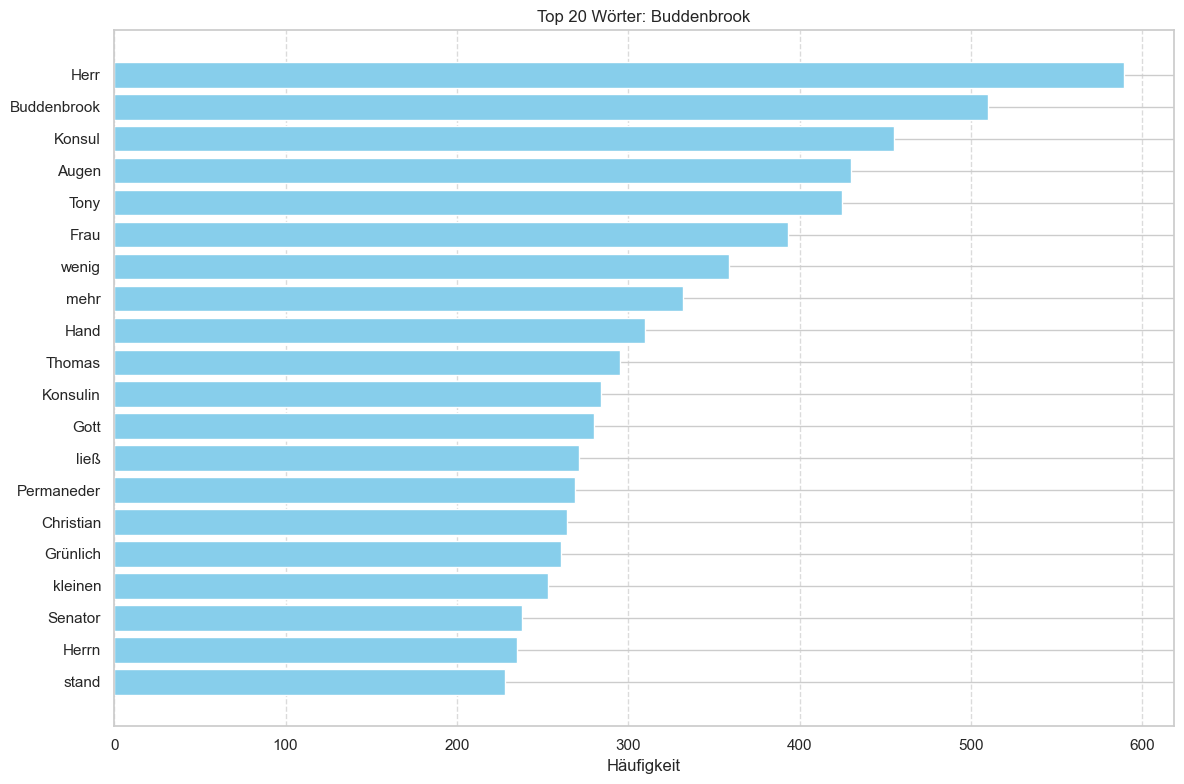

✅ Top-20-Plot gespeichert.


In [ ]:
# ==============================================================================
# ZELLE 410: TOP-20-WÖRTER (Häufigkeitsplot)
# (ehem. Zelle 3)
# Benötigt: saubere_liste aus Zelle 330
# ==============================================================================
from collections import Counter
import matplotlib.pyplot as plt
import os

if saubere_liste:
    zaehler_final = Counter(saubere_liste)
    top_20 = zaehler_final.most_common(20)
    woerter, zahlen = zip(*top_20)

    plt.figure(figsize=(12, 8))
    plt.barh(woerter[::-1], zahlen[::-1], color="skyblue")
    plt.xlabel("Häufigkeit")
    plt.title(f"Top 20 Wörter: {AKTIVES_PROJEKT}")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(
        os.path.join(PFAD_OUTPUT, f"Top20_{AKTIVES_PROJEKT}.png"), bbox_inches="tight"
    )
    plt.show()
    print(f"✅ Top-20-Plot gespeichert.")
else:
    print("⚠️  saubere_liste leer – erst Zelle 330 ausführen.")

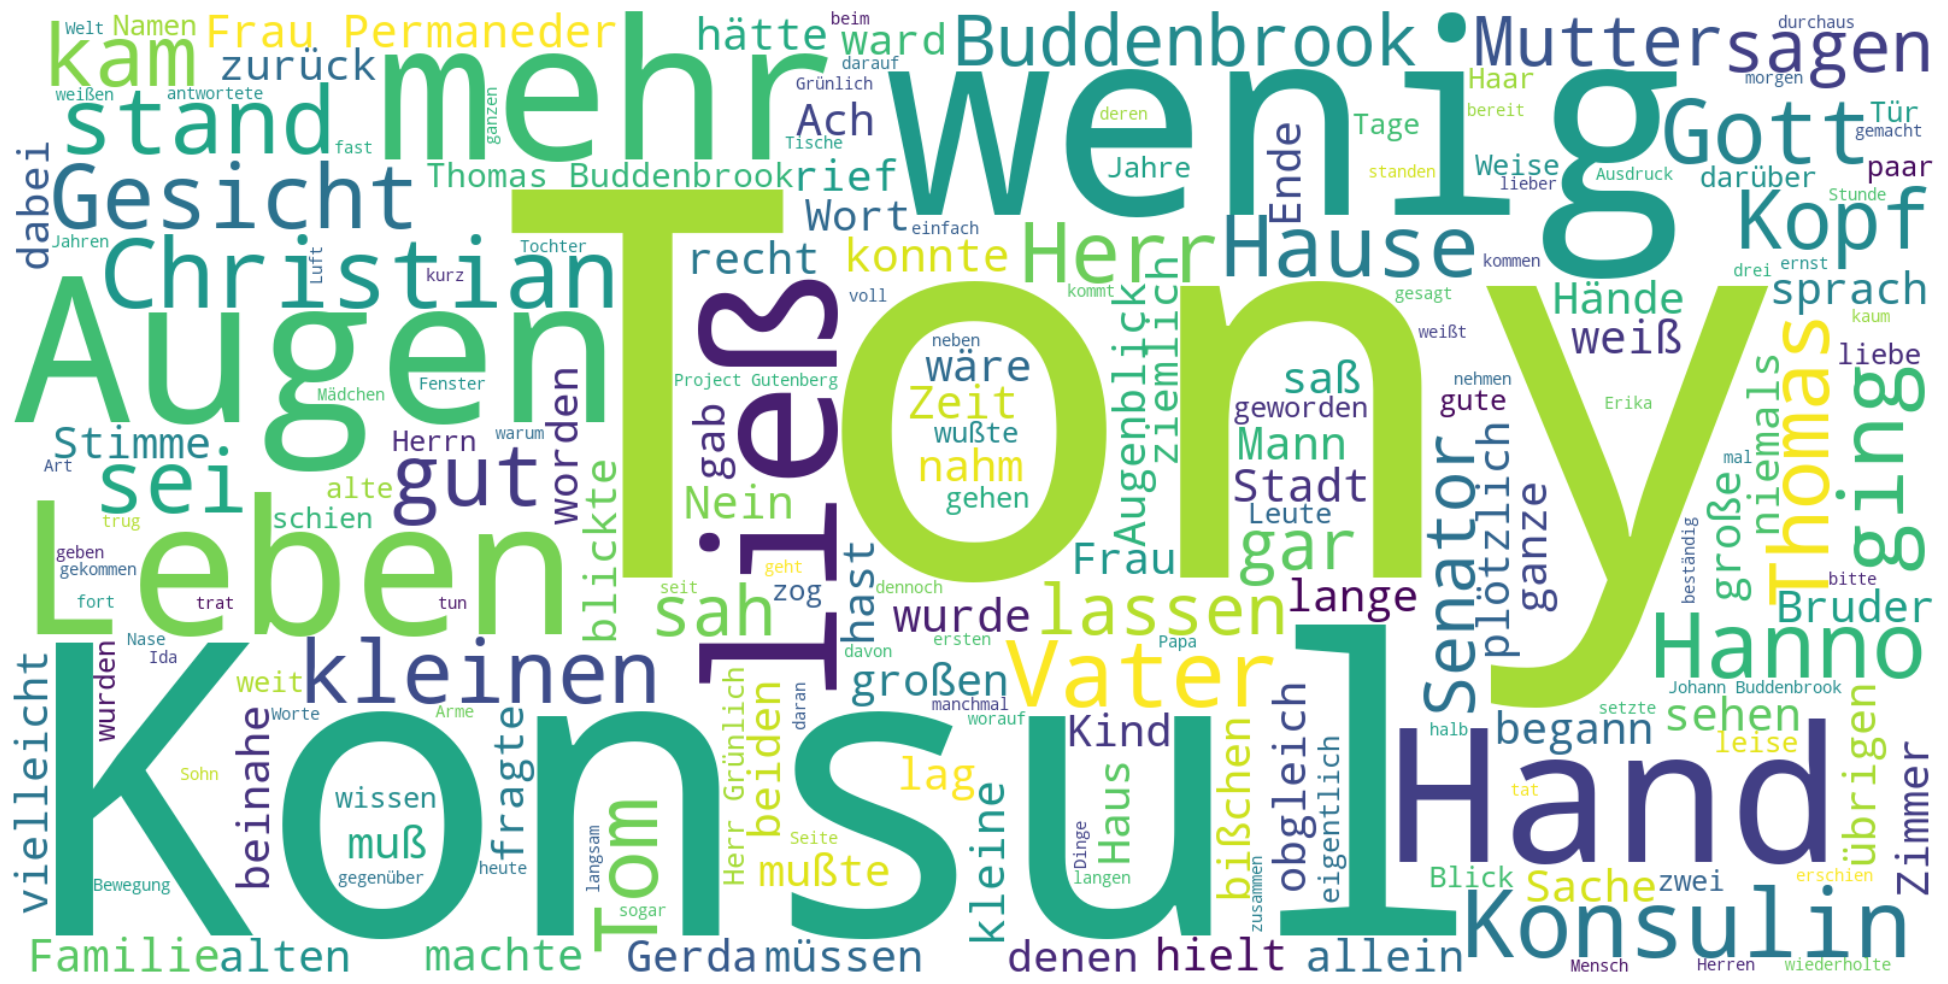

✅ Wordcloud gespeichert: O:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt\Buddenbrook\02_Output\Wordcloud_Buddenbrook.png


In [ ]:
# ==============================================================================
# ZELLE 420: WORDCLOUD generieren & speichern
# (ehem. Zelle 5)
# Benötigt: saubere_liste aus Zelle 330
# ==============================================================================
import matplotlib.pyplot as plt
import os

if saubere_liste:
    try:
        from wordcloud import WordCloud

        text_fuer_cloud = " ".join(saubere_liste)
        wc = WordCloud(width=1600, height=800, background_color="white").generate(
            text_fuer_cloud
        )

        plt.figure(figsize=(20, 10))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.tight_layout()

        bild_pfad = os.path.join(PFAD_OUTPUT, f"Wordcloud_{AKTIVES_PROJEKT}.png")
        wc.to_file(bild_pfad)
        plt.show()
        print(f"✅ Wordcloud gespeichert: {bild_pfad}")
    except ImportError:
        print(
            "⚠️  wordcloud nicht installiert – Zelle 100 (pip-Install) erneut ausführen."
        )
else:
    print("⚠️  saubere_liste leer – erst Zelle 330 ausführen.")

In [ ]:
# ==============================================================================
# ZELLE 430: TEST-CHECK Wildcard-Treffer  [OPTIONAL]
# (ehem. Zelle 2.2)
# Benötigt: wort_liste aus Zelle 320
# ==============================================================================
if wort_liste:
    begriff = "glänz"
    count_exakt = wort_liste.count(begriff)
    count_wildcard = sum(1 for w in wort_liste if w.startswith(begriff))
    print(f"Ergebnis für '{begriff}':")
    print(f"  Exakt   : {count_exakt}")
    print(f"  Wildcard: {count_wildcard}")
else:
    print("⚠️  wort_liste leer – erst Zelle 320 ausführen.")

Ergebnis für 'glänz':
  Exakt   : 0
  Wildcard: 21


In [ ]:
# ==============================================================================
# ZELLE 435: TEST – Kommt mein Wort vor?  [OPTIONAL]
# (ehem. Zelle 90 / v03: 460)
# Benötigt: wort_liste aus Zelle 320
# ==============================================================================
if wort_liste:
    test_wort = "Geld"
    exakt = wort_liste.count(test_wort)
    wildcard = sum(1 for w in wort_liste if w.startswith(test_wort))
    print(f"Ergebnisse für '{test_wort}':")
    print(f"  Exakt          : {exakt} mal")
    print(f"  Als Wortanfang : {wildcard} mal")
else:
    print("⚠️  wort_liste leer – erst Zelle 320 ausführen.")

Ergebnisse für 'Geld':
  Exakt          : 39 mal
  Als Wortanfang : 58 mal


---
## Block E – Chronologische & Thematische Analyse
> Zellen 500–590 · Den Text in Segmente zerlegen und Motive über die Zeit verfolgen.

In [ ]:
# ==============================================================================
# ZELLE 510: CHRONOLOGISCHE SEGMENTANALYSE (10 Teile, Hybrid-Suche)  [MUST]
# (ehem. Zelle 12)
# Benötigt: saubere_liste aus Zelle 330, themen_felder aus Zelle 110
# ==============================================================================
if not saubere_liste:
    print("⚠️  saubere_liste leer – erst Zelle 330 ausführen.")
else:
    anzahl_teile = 10
    segment_laenge = len(saubere_liste) // anzahl_teile
    chronologie_ergebnisse = []

    print(f"🔍 Starte Analyse: {anzahl_teile} Segmente …")

    for i in range(anzahl_teile):
        start = i * segment_laenge
        ende = (i + 1) * segment_laenge if i < anzahl_teile - 1 else len(saubere_liste)
        woerter = saubere_liste[start:ende]

        ergebnis = {"Abschnitt": i + 1, "woerter_im_teil": woerter}

        for thema, begriffe in themen_felder.items():
            zaehler = 0
            for s in begriffe:
                # Option B: mit ! = Präfix-Suche, ohne ! = exakte Suche
                if s.endswith("!"):
                    s_stem = s[:-1].lower()
                    zaehler += sum(1 for w in woerter if w.lower().startswith(s_stem))
                else:
                    zaehler += sum(1 for w in woerter if w.lower() == s.lower())
            ergebnis[thema] = zaehler

        chronologie_ergebnisse.append(ergebnis)

        if i == 0:
            print("-" * 50)
            for thema in themen_felder:
                n = ergebnis[thema]
                print(f"  {'✅' if n > 0 else '❌'} {thema:15}: {n:3} Treffer")
            print("-" * 50)

    print(f"✅ Chronologische Analyse abgeschlossen ({anzahl_teile} Segmente).")

🔍 Starte Analyse: 10 Segmente …
--------------------------------------------------
  ✅ Geld           :  17 Treffer
  ✅ Familie        : 186 Treffer
  ✅ Verfall        :  18 Treffer
  ✅ Glanz          : 166 Treffer
--------------------------------------------------
✅ Chronologische Analyse abgeschlossen (10 Segmente).


In [ ]:
# ==============================================================================
# ZELLE 515: TEST – Häufigste Wörter im ersten Segment  [OPTIONAL]
# (ehem. Zelle 91 / v03: 440)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
from collections import Counter

if chronologie_ergebnisse:
    beispiel = chronologie_ergebnisse[0]["woerter_im_teil"]
    print("Häufigste Wörter im ersten Zehntel des Textes:")
    print(Counter(beispiel).most_common(20))
else:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")

Häufigste Wörter im ersten Zehntel des Textes:
[('Konsul', 99), ('Buddenbrook', 95), ('Herr', 59), ('Vater', 50), ('wenig', 44), ('Jean', 39), ('Augen', 37), ('Hand', 36), ('Konsulin', 35), ('Johann', 34), ('Kopf', 32), ('alte', 31), ('Christian', 31), ('kleinen', 30), ('Tony', 30), ('Gott', 27), ('Gesicht', 26), ('Familie', 25), ('Madame', 25), ('alten', 25)]


In [ ]:
# ==============================================================================
# ZELLE 516: SPEZIAL-TEST – Wort-Varianten-Suche  [OPTIONAL]
# (ehem. Zelle 93 / v03: 450)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
from collections import Counter

if chronologie_ergebnisse:
    suchbegriff = "geld"
    gefundene = [
        w
        for w in chronologie_ergebnisse[0]["woerter_im_teil"]
        if suchbegriff in w.lower()
    ]
    print(f"Gefundene Wörter für '{suchbegriff}':")
    print(Counter(gefundene).most_common())
else:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")

Gefundene Wörter für 'geld':
[('Geld', 3), ('Taschengeld', 2), ('Geldverdienen', 1), ('Geldgier', 1), ('Geldausgeben', 1)]


In [ ]:
# ==============================================================================
# ZELLE 520: NARRATIVE KAPITEL-SEGMENTIERUNG (Kapitel-Zoom)
# (ehem. Zelle 12.5)
# Benötigt: inhalt aus Zelle 210, themen_felder aus Zelle 110
# ==============================================================================
import re
import pandas as pd

if not inhalt:
    print("⚠️  Kein Textinhalt – erst Zelle 210 ausführen.")
else:
    anker_punkte = [
        "Erster Teil",
        "Zweiter Teil",
        "Dritter Teil",
        "Vierter Teil",
        "Fünfter Teil",
        "Sechster Teil",
        "Siebenter Teil",
        "Achter Teil",
        "Neunter Teil",
        "Zehnter Teil",
        "Elfter Teil",
    ]

    pattern = "|".join([f"({re.escape(p)})" for p in anker_punkte])
    segmente_roh = re.split(pattern, inhalt)

    kapitel_daten = []
    aktueller_titel = "Vorspann"

    for seg in segmente_roh:
        if seg is None:
            continue
        if seg in anker_punkte:
            aktueller_titel = seg
        elif len(seg) > 100:
            kap_woerter = re.findall(r"\w+", seg.lower())
            treffer = {}
            for kat, begriffe in themen_felder.items():
                c = 0
                for b in begriffe:
                    # Option B: mit ! = Präfix-Suche, ohne ! = exakte Suche
                    if b.endswith("!"):
                        b_c = b[:-1].lower()
                        c += sum(1 for w in kap_woerter if w.startswith(b_c))
                    else:
                        c += sum(1 for w in kap_woerter if w == b.lower())
                treffer[kat] = c
            kapitel_daten.append(
                {
                    "Teil": aktueller_titel,
                    "Treffer": treffer,
                    "Wortzahl": len(kap_woerter),
                }
            )

    print(f"✅ Narrative Segmentierung: {len(kapitel_daten)} Kapitel analysiert.")
    df_kapitel = pd.DataFrame(
        [{"Teil": d["Teil"], **d["Treffer"]} for d in kapitel_daten]
    )
    display(df_kapitel)

✅ Narrative Segmentierung: 12 Kapitel analysiert.


,Teil,Geld,Familie,Verfall,Glanz
0,Vorspann,0,3,1,0
1,Erster Teil,8,85,8,93
2,Zweiter Teil,10,118,10,98
3,Dritter Teil,18,239,9,136
4,Vierter Teil,25,191,9,123
5,Fünfter Teil,17,154,15,94
6,Sechster Teil,21,221,19,145
7,Siebenter Teil,14,134,12,102
8,Achter Teil,14,277,26,254
9,Neunter Teil,10,178,18,80


In [ ]:
# ==============================================================================
# ZELLE 530: DEEP DIVE – Welche Wörter stecken hinter einem Thema?  [OPTIONAL]
# (ehem. Zelle 12.1)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
from collections import Counter
import pandas as pd

if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:
    ziel_thema = "Geld"  # ← Thema anpassen
    ziel_abschnitt = 9  # ← 0 = 1. Zehntel, 9 = letztes Zehntel

    pd.set_option("display.max_colwidth", None)

    if ziel_thema not in themen_felder:
        print(f"⚠️  Thema '{ziel_thema}' nicht in themen_felder (Zelle 110).")
    else:
        begriffe = themen_felder[ziel_thema]
        text_seg = chronologie_ergebnisse[
            min(ziel_abschnitt, len(chronologie_ergebnisse) - 1)
        ]["woerter_im_teil"]

        details = []
        for s in begriffe:
            # Option B: mit ! = Präfix-Suche, ohne ! = exakte Suche
            if s.endswith("!"):
                s_c = s[:-1].lower()
                treffer = [w for w in text_seg if w.lower().startswith(s_c)]
            else:
                treffer = [w for w in text_seg if w.lower() == s.lower()]
            if treffer:
                details.append(
                    {
                        "Suchbegriff": s,
                        "Treffer": len(treffer),
                        "Varianten": ", ".join(
                            f"{w} ({c}x)" for w, c in Counter(treffer).most_common(10)
                        ),
                    }
                )

        if details:
            df_details = pd.DataFrame(details)
            print(f"🔍 Deep Dive: '{ziel_thema}' – Abschnitt {ziel_abschnitt + 1}")
            display(df_details.style.hide(axis="index"))
            print(f"Gesamt: {df_details['Treffer'].sum()} Treffer")
        else:
            print(
                f"❌ Keine Treffer für '{ziel_thema}' in Abschnitt {ziel_abschnitt + 1}."
            )

🔍 Deep Dive: 'Geld' – Abschnitt 10


Suchbegriff,Treffer,Varianten
Geld,1,Geld (1x)
Geschäft,1,Geschäft (1x)
Mark,1,Mark (1x)


Gesamt: 3 Treffer


✅ Grafik gespeichert: Grafik_Z540_Motivverlauf_Multi_Buddenbrook_20260413_0831.png


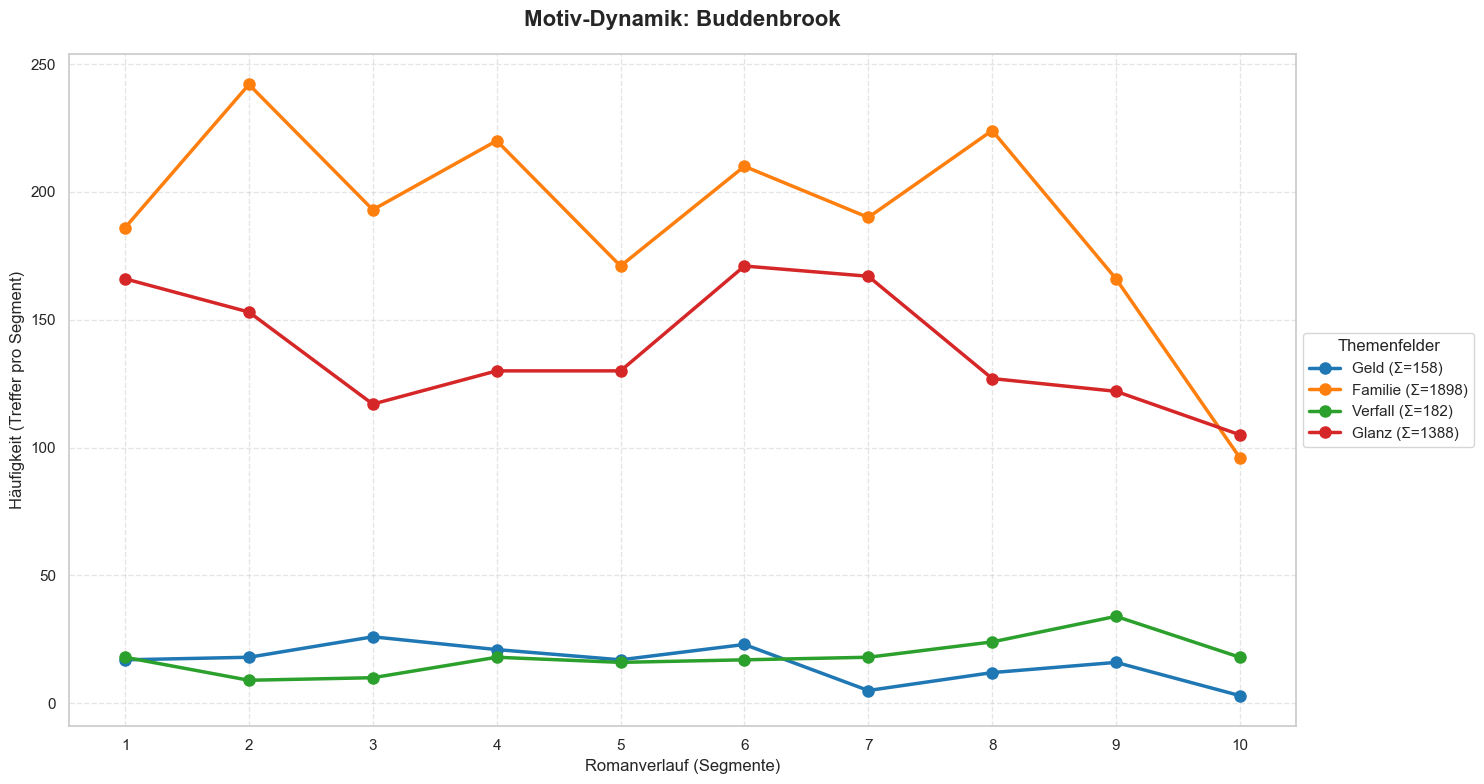

In [ ]:
# ==============================================================================
# ZELLE 540: MOTIVVERLAUF MULTI-THEMEN (Visualisierung)
# (ehem. Zelle 13)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
import matplotlib.pyplot as plt

if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:
    farben = [
        "#1f77b4",
        "#ff7f0e",
        "#2ca02c",
        "#d62728",
        "#9467bd",
        "#8c564b",
        "#e377c2",
        "#7f7f7f",
        "#bcbd22",
    ]

    plt.figure(figsize=(15, 8))
    abschnitte = range(1, len(chronologie_ergebnisse) + 1)

    for i, (kategorie, begriffe) in enumerate(themen_felder.items()):
        y_werte = []
        for seg in chronologie_ergebnisse:
            text = [str(w).lower() for w in seg.get("woerter_im_teil", [])]
            c = 0
            for s in begriffe:
                # Option B: mit ! = Präfix-Suche, ohne ! = exakte Suche
                if s.endswith("!"):
                    s_c = s[:-1].lower()
                    c += sum(1 for w in text if w.lower().startswith(s_c))
                else:
                    c += sum(1 for w in text if w.lower() == s.lower())
            y_werte.append(c)

        plt.plot(
            abschnitte,
            y_werte,
            label=f"{kategorie} (Σ={sum(y_werte)})",
            color=farben[i % len(farben)],
            marker="o",
            markersize=8,
            linewidth=2.5,
        )

    plt.title(
        f"Motiv-Dynamik: {AKTIVES_PROJEKT}", fontsize=16, fontweight="bold", pad=20
    )
    plt.xlabel("Romanverlauf (Segmente)", fontsize=12)
    plt.ylabel("Häufigkeit (Treffer pro Segment)", fontsize=12)
    plt.xticks(abschnitte)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Themenfelder", loc="center left", bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    speichere_grafik(f"Z540_Motivverlauf_Multi_{AKTIVES_PROJEKT}")
    plt.show()

📊 Treffer pro Abschnitt:
 Abschnitt  Geld  Verfall
         1    17       18
         2    18        9
         3    26       10
         4    21       18
         5    17       16
         6    23       17
         7     5       18
         8    12       24
         9    16       34
        10     3       18


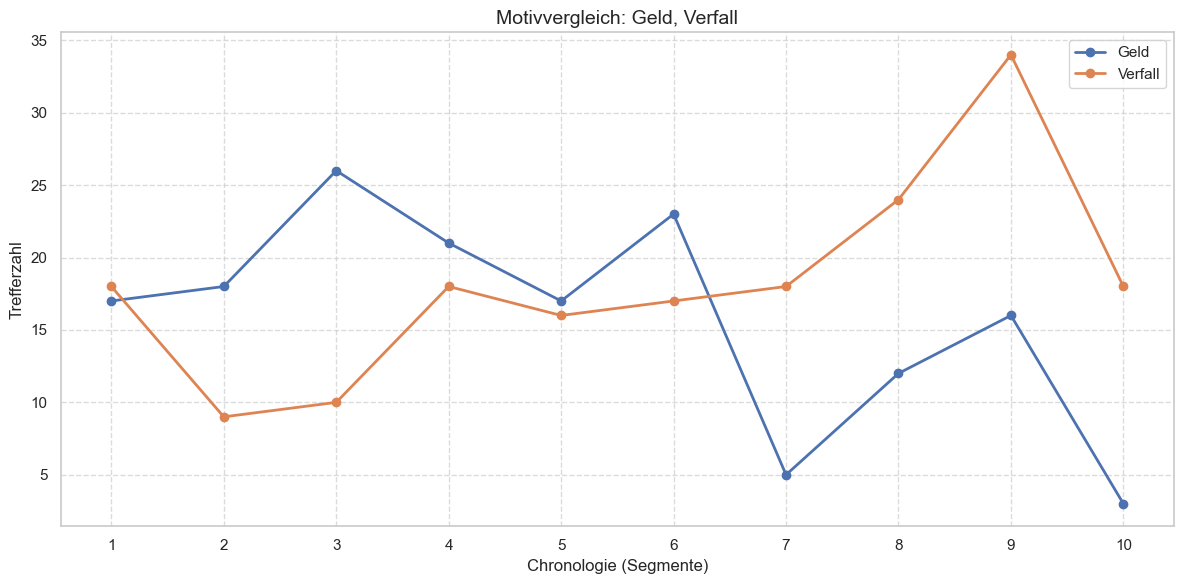

✅ Grafik gespeichert: Grafik_Motivvergleich_Geld_Verfall_20260413_0831.png


<Figure size 1200x600 with 0 Axes>

In [ ]:
# ==============================================================================
# ZELLE 550: CHRONOLOGISCHER MOTIVVERGLEICH (robuste Variante)
# (ehem. Zelle 13.1)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd

if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:
    themen_zum_vergleich = ["Geld", "Verfall"]  # ← anpassen
    plot_data = []

    for nr, daten in enumerate(chronologie_ergebnisse):
        row = {"Abschnitt": nr + 1}
        text_clean = [str(w).lower() for w in daten.get("woerter_im_teil", [])]
        for thema in themen_zum_vergleich:
            if thema in themen_felder:
                suchbegriffe = [
                    s.replace("!", "").lower() for s in themen_felder[thema]
                ]
                row[thema] = sum(1 for w in text_clean if w in suchbegriffe)
            else:
                row[thema] = 0
        plot_data.append(row)

    df_plot = pd.DataFrame(plot_data)
    print("📊 Treffer pro Abschnitt:")
    print(df_plot.to_string(index=False))

    plt.figure(figsize=(12, 6))
    for thema in themen_zum_vergleich:
        plt.plot(
            df_plot["Abschnitt"], df_plot[thema], marker="o", linewidth=2, label=thema
        )
    plt.title(f"Motivvergleich: {', '.join(themen_zum_vergleich)}", fontsize=14)
    plt.xlabel("Chronologie (Segmente)")
    plt.ylabel("Trefferzahl")
    plt.xticks(range(1, len(chronologie_ergebnisse) + 1))
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if "speichere_grafik" in dir():
        speichere_grafik(f"Motivvergleich_{'_'.join(themen_zum_vergleich)}")

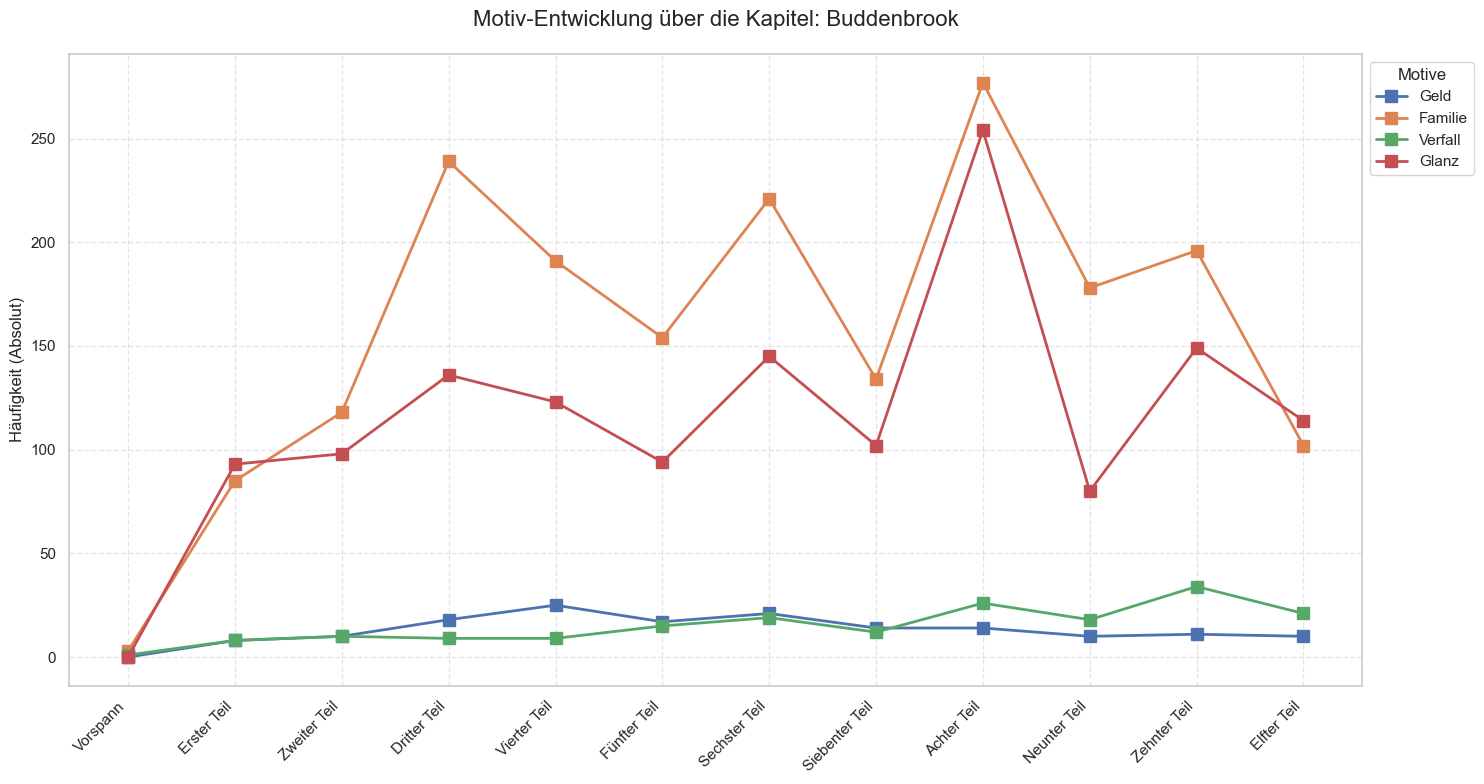

In [ ]:
# ==============================================================================
# ZELLE 560: KAPITEL-VISUALISIERUNG (Linienplot)
# (ehem. Zelle 12.6)
# Benötigt: kapitel_daten aus Zelle 520
# ==============================================================================
import matplotlib.pyplot as plt

if not kapitel_daten:
    print("⚠️  kapitel_daten leer – erst Zelle 520 ausführen.")
else:
    plt.figure(figsize=(15, 8))
    kapitel_namen = [d["Teil"] for d in kapitel_daten]

    for kategorie in themen_felder:
        werte = [d["Treffer"][kategorie] for d in kapitel_daten]
        plt.plot(
            kapitel_namen, werte, label=kategorie, marker="s", markersize=8, linewidth=2
        )

    plt.title(
        f"Motiv-Entwicklung über die Kapitel: {AKTIVES_PROJEKT}", fontsize=16, pad=20
    )
    plt.ylabel("Häufigkeit (Absolut)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Motive", loc="upper left", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

In [ ]:
# ==============================================================================
# ZELLE 570: TEST – Trefferprüfung für ein Segment  [OPTIONAL]
# (ehem. Zelle 14.0)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:
    segment_nr = 0  # 0 = erstes Segment
    test_text = [
        str(w).lower() for w in chronologie_ergebnisse[segment_nr]["woerter_im_teil"]
    ]

    for kat in ["Glanz", "Verfall"]:
        sb = [s.replace("!", "").lower() for s in themen_felder.get(kat, [])]
        treffer = [w for w in test_text if w in sb]
        print(f"--- {kat} ---")
        print(f"  Anzahl: {len(treffer)}")
        print(f"  Wörter: {set(treffer)}\n")

--- Glanz ---
  Anzahl: 25
  Wörter: {'reich', 'gold', 'lachen', 'hell', 'licht', 'glück', 'fest', 'froh', 'sonne'}

--- Verfall ---
  Anzahl: 18
  Wörter: {'müde', 'tod', 'ende'}



---
## Block F – Konkordanz & Sentiment
> Zellen 600–690 · KWIC, Wortfeld-Konkordanz und Stimmungsanalyse.

In [ ]:
# ==============================================================================
# ZELLE 610: KWIC-ANALYSE (Keyword in Context)
# (ehem. Zelle 6.0)
# Benötigt: wort_liste aus Zelle 320
# ==============================================================================
import os

if not wort_liste:
    print("⚠️  wort_liste leer – erst Zelle 320 ausführen.")
else:
    suchwort = "Geld"  # ← Suchbegriff anpassen
    kontext_breite = 5

    ergebnisse = []
    for i, wort in enumerate(wort_liste):
        if wort.lower() == suchwort.lower():
            start = max(0, i - kontext_breite)
            ende = min(len(wort_liste), i + kontext_breite + 1)
            kontext = " ".join(wort_liste[start:ende])
            ergebnisse.append(f"… {kontext} …")

    print(f"🔍 KWIC-Analyse: '{suchwort}' – {len(ergebnisse)} Fundstellen")
    print("-" * 50)
    for fund in ergebnisse[:10]:
        print(fund)

    if ergebnisse:
        export = os.path.join(PFAD_OUTPUT, f"KWIC_{suchwort}_{AKTIVES_PROJEKT}.txt")
        with open(export, "w", encoding="utf-8") as f:
            f.write(f"KWIC '{suchwort}' in {AKTIVES_PROJEKT}\n")
            f.write("\n".join(ergebnisse))
        print(f"\n✅ Fundstellen gespeichert: {os.path.basename(export)}")

🔍 KWIC-Analyse: 'Geld' – 39 Fundstellen
--------------------------------------------------
… elftausend Kuranttaler Das ist gutes Geld Nein nein ich kann nicht …
… Achtung Hat auch gar kein Geld gekostet bemerkte trocken Herr Grätjens …
… seines geschwächten Betriebskapitals war teures Geld durch Transaktionen mit Bankiers und …
… sie Er muß recht viel Geld haben damit wir uns vornehm …
… habe ich nicht nötig mein Geld in die nächste Pfütze zu …
… und Buddenbrooks bekamen eine Menge Geld volle runde 100000 Taler Kurant …
… zu Buddenbrook will mit _avec_ Geld verdienen sagten sie Aber sie …
… spielen und machte ein unglaubliches Geld Kistenmaker Ach ich fürchte beinahe …
… das Regiment führten und allzuviel Geld bekamen Der letztere Punkt ging …
… dem ungeratenen und enterbten Jakob Geld über Geld sandte sie ersparte …

✅ Fundstellen gespeichert: KWIC_Geld_Buddenbrook.txt


In [ ]:
# ==============================================================================
# ZELLE 620: WORTFELD-KONKORDANZ (thematische Suche)
# (ehem. Zelle 6.1)
# Benötigt: wort_liste aus Zelle 320, themen_felder aus Zelle 110
# ==============================================================================
import os

if not wort_liste:
    print("⚠️  wort_liste leer – erst Zelle 320 ausführen.")
else:
    ziel_feld = "Geld"  # ← Wortfeld aus themen_felder wählen
    kontext_breite = 6

    suchbegriffe = themen_felder.get(ziel_feld, [])
    stämme = [s.lower() for s in suchbegriffe]

    print(f"🔎 Wortfeld '{ziel_feld}': {', '.join(suchbegriffe)}")
    print("-" * 50)

    feld_ergebnisse = []
    for i, wort in enumerate(wort_liste):
        if any(st in wort.lower() for st in stämme):
            s = max(0, i - kontext_breite)
            e = min(len(wort_liste), i + kontext_breite + 1)
            kontext = wort_liste[s:i] + [f"[{wort.upper()}]"] + wort_liste[i + 1 : e]
            feld_ergebnisse.append(" ".join(kontext))

    if not feld_ergebnisse:
        print(f"⚠️  Keine Treffer für '{ziel_feld}'.")
    else:
        print(f"📍 {len(feld_ergebnisse)} Treffer:")
        for bsp in feld_ergebnisse[:15]:
            print(f"→ {bsp}")

    export = os.path.join(PFAD_OUTPUT, f"Konkordanz_{ziel_feld}_{AKTIVES_PROJEKT}.txt")
    with open(export, "w", encoding="utf-8") as f:
        f.write(f"Wortfeld: {ziel_feld}\nBegriffe: {suchbegriffe}\n---\n")
        f.write("\n".join(feld_ergebnisse))
    print(f"\n✅ {len(feld_ergebnisse)} Zitate gespeichert: {os.path.basename(export)}")

🔎 Wortfeld 'Geld': Geld, Taler, Börse, Geschäft, Gewinn, Verlust, Courant, Mark
--------------------------------------------------
📍 485 Treffer:
→ Original gesperrt gedruckter Text wurde mit [MARKIERT] Im Original in Antiqua gedruckter Text
→ Antiqua gedruckter Text wurde mit _ [MARKIERT] THOMAS MANN BUDDENBROOKS THOMAS MANN Buddenbrooks
→ Sack Weizen nähme und erbot sich [GESCHÄFTE] mit ihr zu machen Sein rundes
→ seiner giebeligen Vaterstadt lag Abgesehen vom [GESCHÄFTLICHEN] Verkehr aber in gesellschaftlicher Beziehung war
→ der Hauskaufsumme Das ist ein vorteilhaftes [GESCHÄFT] das Papa sehr glatt und gut
→ handelt sich um mehr als elftausend [KURANTTALER] Das ist gutes Geld Nein nein
→ als elftausend Kuranttaler Das ist gutes [GELD] Nein nein ich kann nicht zuraten
→ statt Achtung Hat auch gar kein [GELD] gekostet bemerkte trocken Herr Grätjens der
→ Gott erbarm ich komme von einem [AMTSGESCHÄFT] die Alfstraße hinauf und denke der
→ ein wenig das Mienenspiel des Kaisers [MARKIERT

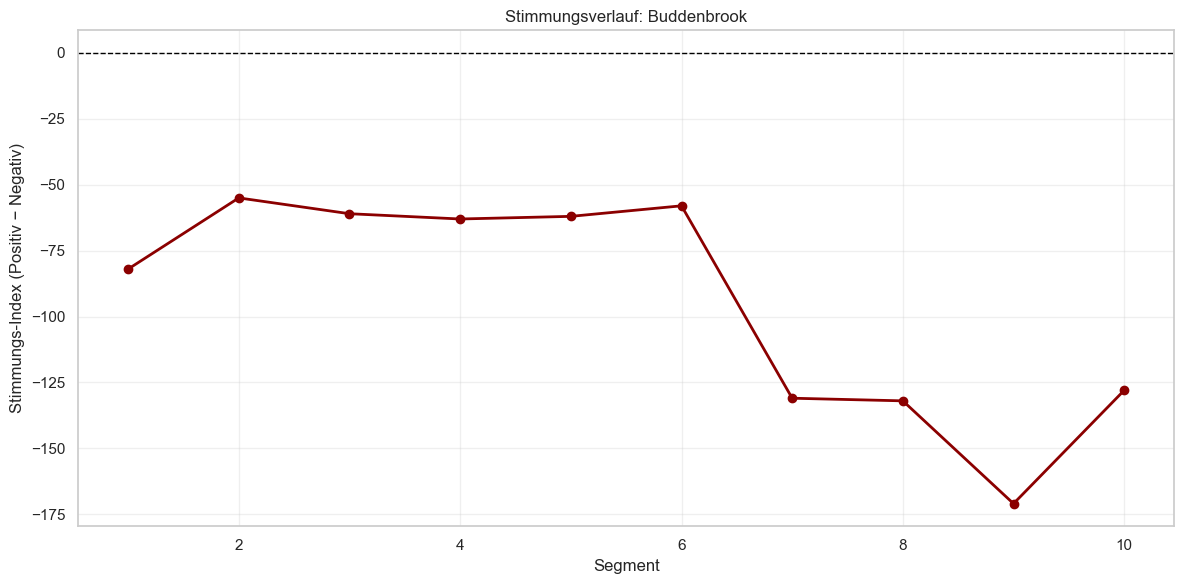

✅ Stimmungs-Analyse abgeschlossen. Grafik: Stimmungsverlauf_Buddenbrook.png


In [ ]:
# ==============================================================================
# ZELLE 630: EMOTIONALE TREND-ANALYSE (Stimmungskurve)
# (ehem. Zelle 14)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
import matplotlib.pyplot as plt, os

if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:
    pos_woerter = ["glück", "erfolg", "lachen", "hoffnung", "gewinn", "fest", "freude"]
    neg_woerter = [
        "tod",
        "krank",
        "angst",
        "verlust",
        "weinen",
        "schmerz",
        "ende",
        "blass",
    ]

    stimmungs_verlauf = []
    for abschnitt in chronologie_ergebnisse:
        woerter = abschnitt["woerter_im_teil"]
        pos = sum(1 for w in woerter if any(p in w.lower() for p in pos_woerter))
        neg = sum(1 for w in woerter if any(n in w.lower() for n in neg_woerter))
        stimmungs_verlauf.append(pos - neg)

    plt.figure(figsize=(12, 6))
    plt.plot(
        range(1, len(stimmungs_verlauf) + 1),
        stimmungs_verlauf,
        marker="o",
        color="darkred",
        linewidth=2,
    )
    plt.axhline(0, color="black", linewidth=1, linestyle="--")
    plt.title(f"Stimmungsverlauf: {AKTIVES_PROJEKT}")
    plt.xlabel("Segment")
    plt.ylabel("Stimmungs-Index (Positiv − Negativ)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    bild_pfad = os.path.join(PFAD_OUTPUT, f"Stimmungsverlauf_{AKTIVES_PROJEKT}.png")
    plt.savefig(bild_pfad)
    plt.show()
    print(f"✅ Stimmungs-Analyse abgeschlossen. Grafik: {os.path.basename(bild_pfad)}")

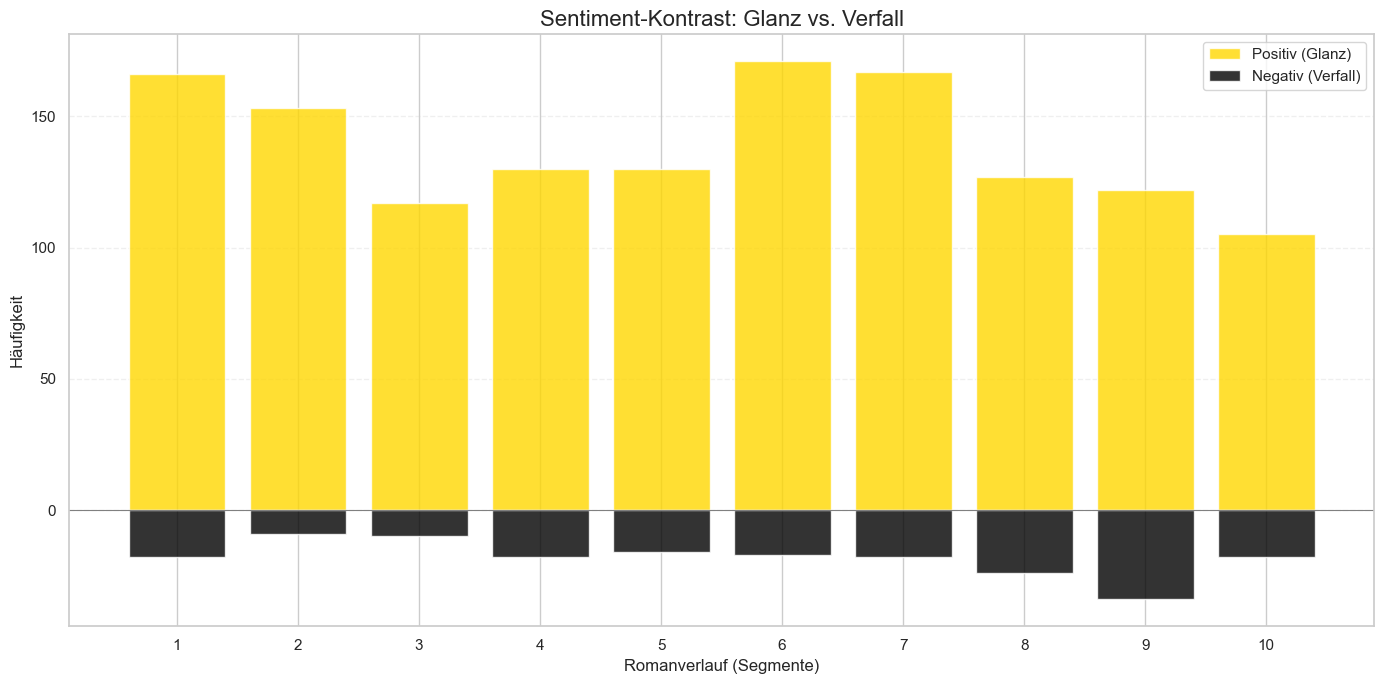

✅ Grafik gespeichert: Grafik_Sentiment_Kontrast_20260413_0831.png


<Figure size 1200x600 with 0 Axes>

In [ ]:
# ==============================================================================
# ZELLE 640: SENTIMENT-KONTRAST (Glanz vs. Verfall – Balkendiagramm)
# (ehem. Zelle 14.1)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np

if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:

    def zaehle_lokal(kat, text_daten):
        c = 0
        for s in themen_felder.get(kat, []):
            # Option B: mit ! = Präfix-Suche, ohne ! = exakte Suche
            if s.endswith("!"):
                s_c = s[:-1].lower()
                c += sum(1 for w in text_daten if w.lower().startswith(s_c))
            else:
                c += sum(1 for w in text_daten if w.lower() == s.lower())
        return c

    thema_pos = "Glanz"
    thema_neg = "Verfall"
    abschnitte = range(1, len(chronologie_ergebnisse) + 1)

    werte_pos, werte_neg = [], []
    for seg in chronologie_ergebnisse:
        txt = [str(w).lower() for w in seg.get("woerter_im_teil", [])]
        werte_pos.append(zaehle_lokal(thema_pos, txt))
        werte_neg.append(zaehle_lokal(thema_neg, txt) * -1)

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.bar(
        abschnitte, werte_pos, color="gold", label=f"Positiv ({thema_pos})", alpha=0.8
    )
    ax.bar(
        abschnitte, werte_neg, color="black", label=f"Negativ ({thema_neg})", alpha=0.8
    )
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(f"Sentiment-Kontrast: {thema_pos} vs. {thema_neg}", fontsize=16)
    ax.set_xlabel("Romanverlauf (Segmente)")
    ax.set_ylabel("Häufigkeit")
    ax.set_xticks(abschnitte)
    ax.legend(loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

    if "speichere_grafik" in dir():
        speichere_grafik("Sentiment_Kontrast")

---
## Block G – Output & Export
> Zellen 700–790 · Ergebnisse als TXT, CSV und Abschlussbericht speichern.

In [ ]:
# ==============================================================================
# ZELLE 710: ANTCONC-EXPORT (.txt)
# (ehem. Zelle 5.1)
# Benötigt: saubere_liste aus Zelle 330
# ==============================================================================
import os

if not saubere_liste:
    print("⚠️  saubere_liste leer – erst Zelle 330 ausführen.")
else:
    os.makedirs(PFAD_ANTCONC, exist_ok=True)
    antconc_name = f"AntConc_Bereinigt_{AKTIVES_PROJEKT}.txt"
    antconc_pfad = os.path.join(PFAD_ANTCONC, antconc_name)

    with open(antconc_pfad, "w", encoding="utf-8") as f:
        f.write(" ".join(saubere_liste))

    print(f"{'='*50}")
    print(f"✅ AntConc-Export erfolgreich")
    print(f"   Datei: {antconc_name}")
    print(f"   Pfad : {PFAD_ANTCONC}")
    print(f"{'='*50}")

✅ AntConc-Export erfolgreich
   Datei: AntConc_Bereinigt_Buddenbrook.txt
   Pfad : O:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt\Buddenbrook\03_AntConc


In [ ]:
# ==============================================================================
# ZELLE 720: CSV-EXPORT der Motiv-Tabelle (mit Zeitstempel)
# (ehem. Zelle 5.2)
# Benötigt: chronologie_ergebnisse aus Zelle 510
# ==============================================================================
import csv, datetime, os

if not chronologie_ergebnisse:
    print("⚠️  chronologie_ergebnisse leer – erst Zelle 510 ausführen.")
else:
    os.makedirs(PFAD_OUTPUT, exist_ok=True)
    jetzt = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
    statistik_name = f"Motiv_Statistik_{AKTIVES_PROJEKT}_{jetzt}.csv"
    statistik_pfad = os.path.join(PFAD_OUTPUT, statistik_name)

    alle_spalten = list(chronologie_ergebnisse[0].keys())
    export_spalten = [s for s in alle_spalten if s != "woerter_im_teil"]

    with open(statistik_pfad, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.DictWriter(
            csvfile, fieldnames=export_spalten, delimiter=";", extrasaction="ignore"
        )
        writer.writeheader()
        for zeile in chronologie_ergebnisse:
            writer.writerow(zeile)

    print(f"{'='*50}")
    print(f"✅ CSV-Export erfolgreich")
    print(f"   Datei: {statistik_name}")
    print(f"   Pfad : {PFAD_OUTPUT}")
    print(f"{'='*50}")

✅ CSV-Export erfolgreich
   Datei: Motiv_Statistik_Buddenbrook_2026-04-13_08-31.csv
   Pfad : O:\OneDrive\Studium\_26SoSe2026\06_Grundlagenübung_Methoden der Textanalyse_2026S\00 DH_Projekt\Buddenbrook\02_Output


In [ ]:
# ==============================================================================
# ZELLE 730: ABSCHLUSS-BERICHT (Konsistenz-Check)
# (ehem. Zelle 99)
# Fasst alle Analyse-Ergebnisse zusammen und prüft die Pipeline-Vollständigkeit.
# ==============================================================================
from collections import Counter

print(f"{'='*60}")
print(f"📊 SYSTEM-ZUSAMMENFASSUNG: {AKTIVES_PROJEKT.upper()}")
print(f"{'='*60}")

if saubere_liste and chronologie_ergebnisse:
    gesamt = len(saubere_liste)
    unique = len(set(saubere_liste))
    top3 = Counter(saubere_liste).most_common(3)

    print(f"📈 KORPUS:")
    print(f"   Bereinigte Wörter : {gesamt:,}")
    print(f"   Einzigartige      : {unique:,}")
    print(f"   Top 3             : {', '.join(f'{w} ({n}x)' for w, n in top3)}")
    print("-" * 60)

    print(f"🎯 MOTIV-RANKING (Gesamt):")
    ranking = {}
    for thema in themen_felder:
        ranking[thema] = sum(seg.get(thema, 0) for seg in chronologie_ergebnisse)
    for motiv, wert in sorted(ranking.items(), key=lambda x: x[1], reverse=True):
        anteil = wert / gesamt * 100 if gesamt > 0 else 0
        print(f"   {motiv:15}: {wert:5} Treffer ({anteil:.2f} %)")
    print("-" * 60)

    hauptmotiv = max(ranking, key=ranking.get)
    print(f"✅ Pipeline vollständig durchlaufen.")
    print(f"   Hauptmotiv: {hauptmotiv.upper()}")
else:
    fehlend = []
    if not saubere_liste:
        fehlend.append("saubere_liste (Zelle 330)")
    if not chronologie_ergebnisse:
        fehlend.append("chronologie_ergebnisse (Zelle 510)")
    print(f"⚠️  Datenlücke – fehlende Variablen: {', '.join(fehlend)}")
    print("   → Bitte 'Alle ausführen' neu starten.")

print(f"{'='*60}")

📊 SYSTEM-ZUSAMMENFASSUNG: BUDDENBROOK
📈 KORPUS:
   Bereinigte Wörter : 115,472
   Einzigartige      : 26,699
   Top 3             : Herr (589x), Buddenbrook (510x), Konsul (455x)
------------------------------------------------------------
🎯 MOTIV-RANKING (Gesamt):
   Familie        :  1898 Treffer (1.64 %)
   Glanz          :  1388 Treffer (1.20 %)
   Verfall        :   182 Treffer (0.16 %)
   Geld           :   158 Treffer (0.14 %)
------------------------------------------------------------
✅ Pipeline vollständig durchlaufen.
   Hauptmotiv: FAMILIE


---
## Block H – Backup & Archiv
> Zellen 800–890 · Einzelzellen-Archivierung und versioniertes Full-Backup.

In [ ]:
# ==============================================================================
# ZELLE 810: ARCHIV-GENERATOR (Einzelzelle versioniert exportieren)
# (ehem. Zelle 910)
# Workflow: 1) gewünschte Zelle mit %%writefile spezial_analyse_temp.py speichern
#           2) Diese Zelle ausführen → erzeugt versioniertes .ipynb im 04_Archiv
# ==============================================================================
import nbformat as nbf
import os, re, datetime


def export_zelle_zu_archiv():
    temp_file = "spezial_analyse_temp.py"
    if not os.path.exists(temp_file):
        print("ℹ️  Keine temporäre Datei 'spezial_analyse_temp.py' gefunden.")
        print(
            "   → Zelle mit '%%writefile spezial_analyse_temp.py' beginnen, dann erneut ausführen."
        )
        return

    with open(temp_file, "r", encoding="utf-8") as f:
        zelle_inhalt = f.read()

    match_nr = re.search(r"#\s*ZELLE\s*([\d\.]+)", zelle_inhalt, re.IGNORECASE)
    match_titel = re.search(r"#\s*Titel[:\s]+(.*)", zelle_inhalt, re.IGNORECASE)

    nr_str = match_nr.group(1).replace(".", "_") if match_nr else "Unbekannt"
    titel_raw = match_titel.group(1).strip() if match_titel else "Analyse"
    titel_clean = re.sub(r"[^\w\s-]", "", titel_raw).replace(" ", "_")[:60]

    base_name = f"{nr_str}_{titel_clean}"
    os.makedirs(PFAD_ARCHIV, exist_ok=True)

    # Versionsnummer ermitteln
    v = 1
    while os.path.exists(os.path.join(PFAD_ARCHIV, f"{base_name}_v{v:03d}.ipynb")):
        v += 1

    dateiname = f"{base_name}_v{v:03d}.ipynb"
    voller_pfad = os.path.join(PFAD_ARCHIV, dateiname)

    nb = nbf.v4.new_notebook()
    jetzt = datetime.datetime.now().strftime("%d.%m.%Y %H:%M")
    header = f"# Archiv: {titel_raw}\n**Zelle:** {nr_str.replace('_', '.')} | **Zeit:** {jetzt} | **Version:** v{v:03d}"
    nb["cells"] = [nbf.v4.new_markdown_cell(header), nbf.v4.new_code_cell(zelle_inhalt)]

    with open(voller_pfad, "w", encoding="utf-8") as f:
        nbf.write(nb, f)

    os.remove(temp_file)
    print(f"✅ Archiviert: {dateiname}")
    print(f"   Pfad: {PFAD_ARCHIV}")


export_zelle_zu_archiv()

ℹ️  Keine temporäre Datei 'spezial_analyse_temp.py' gefunden.
   → Zelle mit '%%writefile spezial_analyse_temp.py' beginnen, dann erneut ausführen.


In [ ]:
# ==============================================================================
# ZELLE 820: FULL-BACKUP (versioniert, mit Geräte-Kennung)
# (ehem. Zelle 999)
# Setzt BACKUP_JETZT_AUSFÜHREN = True, um das Backup tatsächlich durchzuführen.
# Bei „Alle ausführen" mit False: kein ungewolltes Backup, kein Fehler.
# ==============================================================================
import os, shutil, datetime, glob

BACKUP_JETZT_AUSFÜHREN = False  # ← True = Backup aktiv | False = übersprungen


def sichere_gesamtes_notebook():
    if not BACKUP_JETZT_AUSFÜHREN:
        print("⏭️  Backup übersprungen (BACKUP_JETZT_AUSFÜHREN = False).")
        return

    # Notebook-Datei ermitteln (zuletzt geänderte .ipynb im aktuellen Verzeichnis)
    ipynb_dateien = glob.glob("*.ipynb")
    if not ipynb_dateien:
        print("❌ Keine .ipynb-Datei im aktuellen Ordner gefunden!")
        return

    aktuelle_datei = max(ipynb_dateien, key=os.path.getmtime)
    basis_name = os.path.splitext(aktuelle_datei)[0]
    heute = datetime.datetime.now().strftime("%Y-%m-%d")
    geraet = os.environ.get("COMPUTERNAME", os.environ.get("HOSTNAME", "GERAET"))

    os.makedirs(PFAD_BACKUP, exist_ok=True)

    # Versionsnummer ermitteln
    v = 1
    while True:
        dateiname = f"BACKUP_{heute}_{geraet}_{basis_name}_v{v:03d}.ipynb"
        if not os.path.exists(os.path.join(PFAD_BACKUP, dateiname)):
            break
        v += 1

    ziel = os.path.join(PFAD_BACKUP, dateiname)
    try:
        shutil.copy2(aktuelle_datei, ziel)
        print(f"✅ Full-Backup erfolgreich!")
        print(f"   Quelle  : {aktuelle_datei}")
        print(f"   Ziel    : {dateiname}")
        print(f"   Version : v{v:03d}")
    except Exception as e:
        print(f"❌ Backup-Fehler: {e}")


sichere_gesamtes_notebook()

⏭️  Backup übersprungen (BACKUP_JETZT_AUSFÜHREN = False).


---
## Block I – Pädagogische Zellen (optional)
> Zellen 900–990 · Grundlagen-Übungen. Kein Einfluss auf die Analyse-Pipeline.

In [ ]:
# ==============================================================================
# ZELLE 910: TRAINING – Einrückungen (Python-Grundlage)  [OPTIONAL]
# (ehem. Zelle 1.1)
# ==============================================================================
def datei_suche(ordner_name):
    print("Suche im Ordner: " + ordner_name)
    dateien = ["kapitel1.txt", "kapitel2.txt"]
    return dateien


ergebnis = datei_suche("Buddenbrooks_Archiv")
print("Gefundene Dateien:", ergebnis)

Suche im Ordner: Buddenbrooks_Archiv
Gefundene Dateien: ['kapitel1.txt', 'kapitel2.txt']


In [ ]:
# ==============================================================================
# ZELLE 920: TRAINING – Variablen anlegen  [OPTIONAL]
# (ehem. Zelle 7)
# ==============================================================================
titel_demo = "Buddenbrooks"
autor_demo = "Thomas Mann"
erscheinungsjahr = 1901
print(titel_demo)
print(erscheinungsjahr)

Buddenbrooks
1901


In [ ]:
# ==============================================================================
# ZELLE 930: TRAINING – Name vs. Inhalt (Variable vs. String-Literal)  [OPTIONAL]
# (ehem. Zelle 8)
# ==============================================================================
stadt = "Lübeck"
print(stadt)  # Gibt den Inhalt der Variable aus: Lübeck
print("stadt")  # Gibt den String-Literal aus:    stadt

Lübeck
stadt


In [ ]:
# ==============================================================================
# ZELLE 940: TRAINING – String-Concatenation  [OPTIONAL]
# (ehem. Zelle 9)
# ==============================================================================
vorname = "Thomas"
nachname = "Mann"
print("Versuch 1 (ohne Leerzeichen):", vorname + nachname)
print("Versuch 2 (mit Leerzeichen):", vorname + " " + nachname)

charakter = "Tony"
familie = "Buddenbrook"
satz = charakter + " gehört zur Familie " + familie + "."
print(satz)

Versuch 1 (ohne Leerzeichen): ThomasMann
Versuch 2 (mit Leerzeichen): Thomas Mann
Tony gehört zur Familie Buddenbrook.


In [ ]:
# ==============================================================================
# ZELLE 950: TRAINING – Datentypen / TypeError-Falle  [OPTIONAL]
# (ehem. Zelle 10)
# ==============================================================================
titel_demo = "Buddenbrooks"
jahr = 1901
# Richtig: Integer mit str() konvertieren
print(titel_demo + " erschien im Jahr " + str(jahr))

Buddenbrooks erschien im Jahr 1901


In [ ]:
# ==============================================================================
# ZELLE 960: TRAINING – Typ-Konvertierung (int/str)  [OPTIONAL]
# (ehem. Zelle 11)
# ==============================================================================
zahl_text_1 = "10"
zahl_text_2 = "20"
echte_1 = int(zahl_text_1)
echte_2 = int(zahl_text_2)
print(f"Addition      : {echte_1 + echte_2}")
print(f"Multiplikation: {echte_1 * echte_2}")
print(f"Datentyp      : {type(echte_1)}")

Addition      : 30
Multiplikation: 200
Datentyp      : <class 'int'>
